In [6]:


import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np

from module.dynamic_architect import Neural_Network
from module.layers import Linear
from module.activations import ReLU, Sigmoid
from module.losses import BCE
from module.train_loop import train
from data.generate import generate_distortedrings_data 
from module.gradient_diagnostics import gradient_norm, training_norm

def Predict(X,model): 
    A = X 
    for layer in model: 
        A = layer.forward(A) 
    return A
train_accs = []
test_accs = []



for seed in range(10):
    
    np.set_printoptions(suppress=True) 
    depth2 = Neural_Network([2,16,16,1]) 
    model = depth2.layers 
    X,y =  generate_distortedrings_data(2000,seed) 
    loss_func = BCE()
    loss_history = train(model,loss_func,X,y,1000,32,0.001) 
    
    
    
    
    y_hat = Predict(X,model) 
    y_pred = (y_hat > 0.5).astype(int)
    training_accuracy = np.mean(y_pred == y)
    
    
    X_test,y_test =  generate_distortedrings_data(400,seed+100)
    y_hat_test = Predict(X_test,model)
    y_pred_test = (y_hat_test > 0.5).astype(int)
    testing_accuracy = np.mean(y_pred_test == y_test)
    
    train_accs.append(training_accuracy)
    test_accs.append(testing_accuracy)

print(f"TRAIN acc: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}")
print(f"TEST  acc: {np.mean(test_accs):.4f} ± {np.std(test_accs):.4f}")



TRAIN acc: 0.9686 ± 0.0104
TEST  acc: 0.9597 ± 0.0156


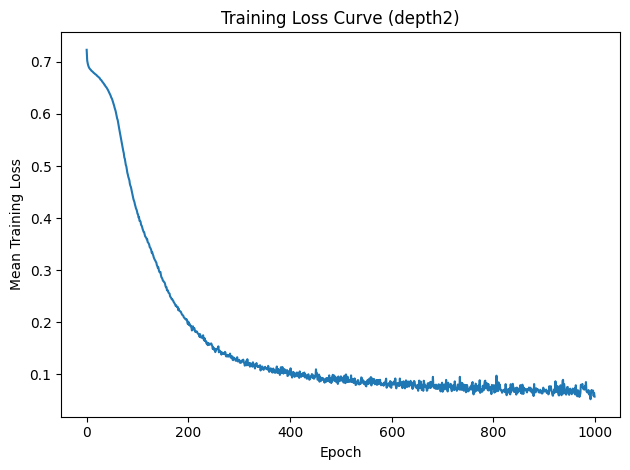

In [8]:
batch_per_epoch = int(np.ceil(len(X) / 32))
epoch_loss = [
    np.mean(loss_history[i*batch_per_epoch:(i+1)*batch_per_epoch])
    for i in range(1000)
]
import os
import matplotlib.pyplot as plt


os.makedirs("../figures", exist_ok=True)

plt.figure()
plt.plot(epoch_loss)
plt.xlabel("Epoch")
plt.ylabel("Mean Training Loss")
plt.title("Training Loss Curve (depth2)")

plt.tight_layout()

plt.savefig(
    "../figures/day31_distortedrings_depth2_losscurve.png",
    dpi=300
)

plt.show()
plt.close()


In [3]:
last_100 = epoch_loss[900:]
for i in range(0,100,10): 
    print(" ".join(f"{x:8.4f}" for x in last_100[i:i+10]))
    

  0.0706   0.0672   0.0703   0.0702   0.0708   0.0644   0.0673   0.0672   0.0618   0.0630
  0.0774   0.0711   0.0710   0.0773   0.0680   0.0661   0.0610   0.0591   0.0644   0.0711
  0.0645   0.0697   0.0869   0.0709   0.0664   0.0667   0.0778   0.0656   0.0611   0.0597
  0.0711   0.0633   0.0793   0.0620   0.0601   0.0642   0.0882   0.0897   0.0633   0.0814
  0.0742   0.0690   0.0636   0.0613   0.0659   0.0756   0.0761   0.0670   0.0628   0.0609
  0.0693   0.0728   0.0652   0.0702   0.0621   0.0647   0.0728   0.0670   0.0649   0.0678
  0.0736   0.0614   0.0793   0.0675   0.0629   0.0581   0.0696   0.0690   0.0642   0.0569
  0.0590   0.0636   0.0803   0.0771   0.0793   0.0817   0.0752   0.0717   0.0737   0.0709
  0.0777   0.0768   0.0854   0.0680   0.0662   0.0655   0.0654   0.0700   0.0620   0.0632
  0.0588   0.0524   0.0654   0.0702   0.0665   0.0659   0.0692   0.0588   0.0644   0.0575


AVG GRADIENT NORM:  42.38355873389207
GRADIENT NORM STANDARD DEVIATION:  4.7057022742827845
COEFFICIENT OF VARIATION:  0.11102659651181823


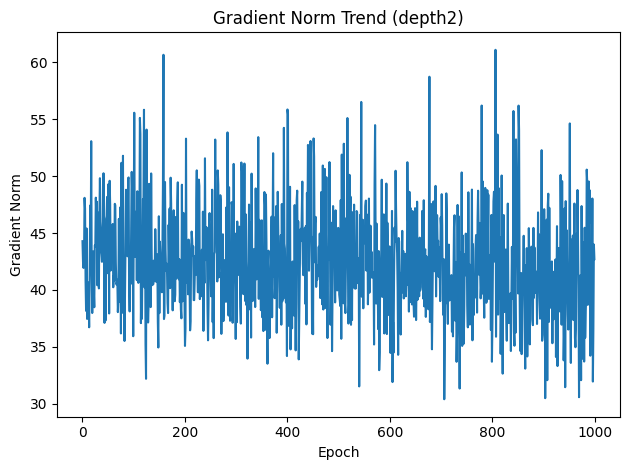

In [9]:
epochs_norm = training_norm(model,loss_func,X,y,1000,32,0.001) 
print("AVG GRADIENT NORM: ", np.mean(epochs_norm))
print("GRADIENT NORM STANDARD DEVIATION: ",np.std(epochs_norm))
print("COEFFICIENT OF VARIATION: ", np.std(epochs_norm)/np.mean(epochs_norm))

plt.figure()
plt.plot(epochs_norm)
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.title(f"Gradient Norm Trend (depth2)")

plt.tight_layout()

plt.savefig(
    f"../figures/day31_distortedrings_depth2_gradnorm_plot.png",
    dpi=300
)

plt.show()
plt.close()